# Custom MT Pair Results Notebook

Run inside `custom-mt-pairs/`. Loads 2-task custom MT result summaries with task ID.


In [1]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

ROOT = Path(".")
print("Working directory:", ROOT.resolve())


Working directory: C:\Users\Michalis\Documents\GitHub\Metaworld-Tests\custom-mt-pairs


## 1. Load results


In [2]:

summary_files = [p for p in ROOT.rglob("*_summary.csv") if "skipped" not in p.name.lower() and "checkpoint" not in p.name.lower()]
dfs = []
for p in summary_files:
    try:
        df = pd.read_csv(p)
        if {"config", "task_name", "success_rate"}.issubset(df.columns):
            exp = p.name.replace("_summary.csv", "")
            df["experiment"] = exp
            df["source_file"] = str(p)
            dfs.append(df)
    except Exception as e:
        print("Could not read", p, e)

data = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
print("Summary files:")
for p in summary_files:
    print(" -", p)
print("Loaded rows:", len(data))
display(data.head())


Summary files:
 - custom_basketball_pick_place\basketball_pickplace_eval_results\basketball_pickplace_eval_summary.csv
 - custom_button_push\button_push_eval_results\button_push_eval_summary.csv
 - custom_button_push\button_push_eval_results_100ep_3seeds\button_push_eval_summary.csv
 - custom_button_push\individual_env_eval_results\individual_env_final_summary.csv
 - custom_push_pickplace\push_pickplace_eval_results\push_pickplace_summary.csv
Loaded rows: 24


,config,task_name,success_rate,avg_return,std_return,avg_episode_length,std_episode_length,avg_first_success_step,median_first_success_step,episodes,experiment,source_file
0,base,basketball-v3,0.96,3632.396014,1659.094981,500.0,0.0,55.312500,54.0,50,basketball_pickplace_eval,custom_basketball_pick_place\basketball_pickpl...
1,base,pick-place-v3,1.00,4554.925679,409.583544,500.0,0.0,49.880000,43.0,50,basketball_pickplace_eval,custom_basketball_pick_place\basketball_pickpl...
2,careful,basketball-v3,1.00,4573.853442,10.001515,500.0,0.0,54.980000,54.0,50,basketball_pickplace_eval,custom_basketball_pick_place\basketball_pickpl...
3,careful,pick-place-v3,1.00,4617.359016,127.590434,500.0,0.0,42.220000,41.0,50,basketball_pickplace_eval,custom_basketball_pick_place\basketball_pickpl...
4,explore,basketball-v3,0.90,1787.814397,1890.032914,500.0,0.0,68.111111,62.0,50,basketball_pickplace_eval,custom_basketball_pick_place\basketball_pickpl...


## 2. Tables and plots


,config,task_name,success_rate,avg_return,std_return,avg_episode_length,std_episode_length,avg_first_success_step,median_first_success_step,episodes,experiment,source_file
0,base,basketball-v3,0.960000,3632.396014,1659.094981,500.000000,0.000000,55.312500,54.0,50,basketball_pickplace_eval,custom_basketball_pick_place\basketball_pickpl...
1,base,pick-place-v3,1.000000,4554.925679,409.583544,500.000000,0.000000,49.880000,43.0,50,basketball_pickplace_eval,custom_basketball_pick_place\basketball_pickpl...
2,careful,basketball-v3,1.000000,4573.853442,10.001515,500.000000,0.000000,54.980000,54.0,50,basketball_pickplace_eval,custom_basketball_pick_place\basketball_pickpl...
3,careful,pick-place-v3,1.000000,4617.359016,127.590434,500.000000,0.000000,42.220000,41.0,50,basketball_pickplace_eval,custom_basketball_pick_place\basketball_pickpl...
4,explore,basketball-v3,0.900000,1787.814397,1890.032914,500.000000,0.000000,68.111111,62.0,50,basketball_pickplace_eval,custom_basketball_pick_place\basketball_pickpl...
5,explore,pick-place-v3,1.000000,4125.376605,1016.149159,500.000000,0.000000,42.100000,42.0,50,basketball_pickplace_eval,custom_basketball_pick_place\basketball_pickpl...
6,base,button-press-v3,1.000000,4377.957656,51.100159,500.000000,0.000000,37.660000,38.0,250,button_push_eval,custom_button_push\button_push_eval_results\bu...
12,base,button-press-v3,1.000000,64.174571,5.758191,37.386667,1.675264,37.386667,37.0,300,button_push_eval,custom_button_push\button_push_eval_results_10...
7,base,push-v3,0.916000,4229.004049,1244.546427,500.000000,0.000000,49.082969,43.0,250,button_push_eval,custom_button_push\button_push_eval_results\bu...
13,base,push-v3,0.973333,159.323854,295.180069,50.660000,74.602970,38.349315,38.0,300,button_push_eval,custom_button_push\button_push_eval_results_10...


task_name,basketball-v3,pick-place-v3
config,,
base,0.96,1.0
careful,1.00,1.0
explore,0.90,1.0


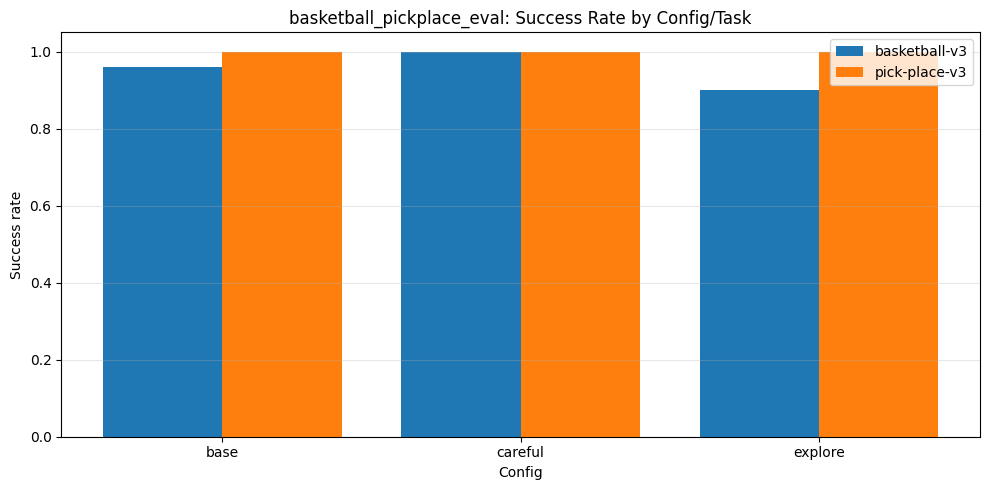

task_name,button-press-v3,push-v3
config,,
base,1.0,0.944667
careful,1.0,0.972000
explore,1.0,0.550000


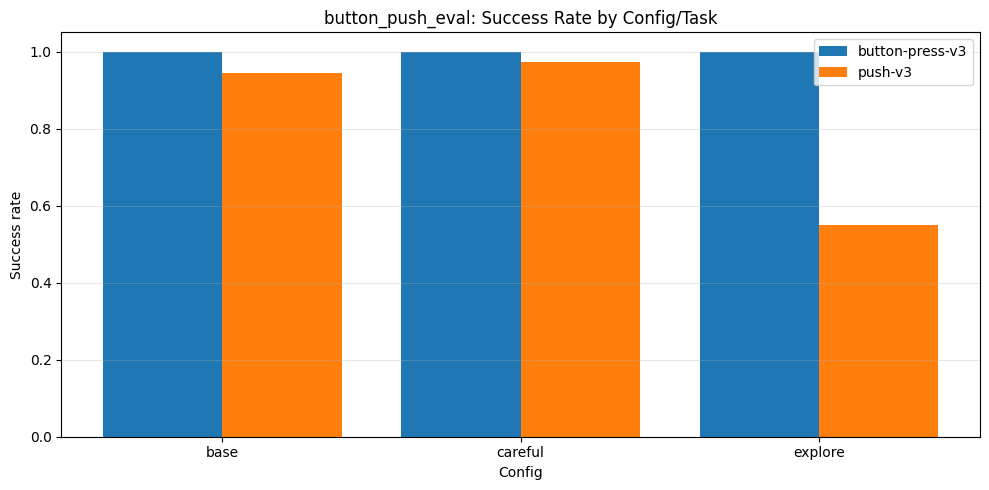

task_name,pick-place-v3,push-v3
config,,
base,1.000000,0.973333
careful,1.000000,1.000000
explore,0.946667,0.960000


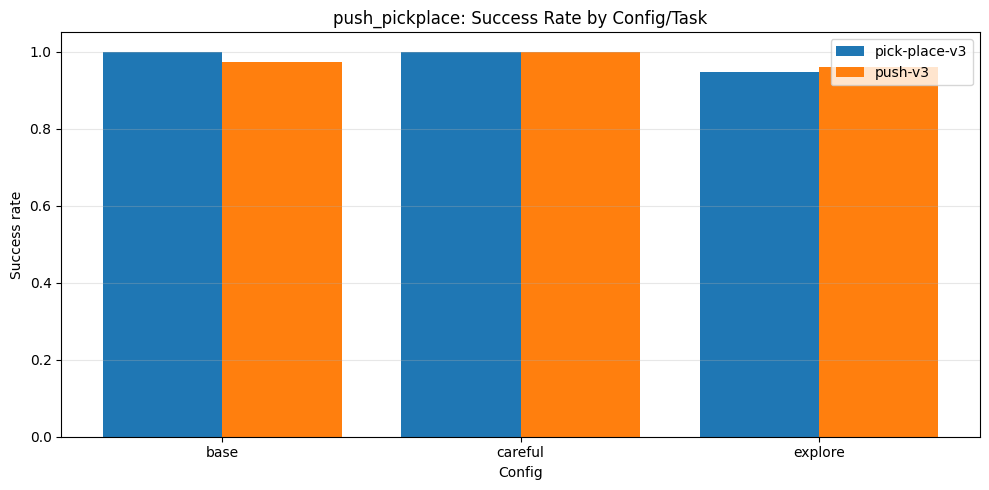

,experiment,config,mean_success,min_success,mean_return,total_episodes
1,basketball_pickplace_eval,careful,1.000000,1.000000,4595.606229,100
0,basketball_pickplace_eval,base,0.980000,0.960000,4093.660847,100
2,basketball_pickplace_eval,explore,0.950000,0.900000,2956.595501,100
4,button_push_eval,careful,0.986000,0.964000,2242.103706,1100
3,button_push_eval,base,0.972333,0.916000,2207.615032,1100
5,button_push_eval,explore,0.775000,0.540000,1933.736893,1100
7,push_pickplace,careful,1.000000,1.000000,93.324801,600
6,push_pickplace,base,0.986667,0.973333,107.699632,600
8,push_pickplace,explore,0.953333,0.946667,96.008047,600


,experiment,config,mean_success,min_success,mean_return,total_episodes
1,basketball_pickplace_eval,careful,1.000,1.000,4595.606229,100
4,button_push_eval,careful,0.986,0.964,2242.103706,1100
7,push_pickplace,careful,1.000,1.000,93.324801,600


In [3]:

if data.empty:
    print("No compatible summary CSVs found.")
else:
    display(data.sort_values(["experiment", "config", "task_name"]))

    for exp in sorted(data["experiment"].unique()):
        d = data[data["experiment"] == exp]
        pivot = d.pivot_table(index="config", columns="task_name", values="success_rate")
        display(pivot)

        configs = list(pivot.index)
        tasks = list(pivot.columns)
        x = np.arange(len(configs))
        width = 0.8 / max(len(tasks), 1)

        fig, ax = plt.subplots(figsize=(10, 5))
        for i, task in enumerate(tasks):
            ax.bar(x + (i - (len(tasks)-1)/2) * width, pivot[task], width, label=task)
        ax.set_title(f"{exp}: Success Rate by Config/Task")
        ax.set_xlabel("Config")
        ax.set_ylabel("Success rate")
        ax.set_ylim(0, 1.05)
        ax.set_xticks(x)
        ax.set_xticklabels(configs)
        ax.grid(True, axis="y", alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()

    ranking = (
        data.groupby(["experiment", "config"])
        .agg(
            mean_success=("success_rate", "mean"),
            min_success=("success_rate", "min"),
            mean_return=("avg_return", "mean") if "avg_return" in data.columns else ("success_rate", "mean"),
            total_episodes=("episodes", "sum") if "episodes" in data.columns else ("success_rate", "count"),
        )
        .reset_index()
        .sort_values(["experiment", "mean_success", "min_success"], ascending=[True, False, False])
    )
    display(ranking)
    display(ranking.groupby("experiment").head(1))


## 3. Save notebook outputs


In [4]:

out_dir = Path("notebook_outputs")
fig_dir = out_dir / "figures"
out_dir.mkdir(exist_ok=True)
fig_dir.mkdir(exist_ok=True)

if not data.empty:
    data.to_csv(out_dir / "loaded_summary_results.csv", index=False)

    for exp in sorted(data["experiment"].unique()):
        d = data[data["experiment"] == exp]
        pivot = d.pivot_table(index="config", columns="task_name", values="success_rate")
        configs = list(pivot.index)
        tasks = list(pivot.columns)
        x = np.arange(len(configs))
        width = 0.8 / max(len(tasks), 1)

        fig, ax = plt.subplots(figsize=(10, 5))
        for i, task in enumerate(tasks):
            ax.bar(x + (i - (len(tasks)-1)/2) * width, pivot[task], width, label=task)
        ax.set_title(f"{exp}: Success Rate by Config/Task")
        ax.set_xlabel("Config")
        ax.set_ylabel("Success rate")
        ax.set_ylim(0, 1.05)
        ax.set_xticks(x)
        ax.set_xticklabels(configs)
        ax.grid(True, axis="y", alpha=0.3)
        ax.legend()
        plt.tight_layout()
        fig.savefig(fig_dir / f"{exp}_success_by_config_task.png", dpi=200, bbox_inches="tight")
        plt.close(fig)

print("Saved outputs to", out_dir)


Saved outputs to notebook_outputs
